# Principal Components Regression (PCR)

## What it does
PCR is a **two-stage supervised prediction pipeline**:
1. **PCA** (unsupervised) reduces the feature matrix to `k` orthogonal principal components
2. **Ridge regression** is fit on those `k` components to predict the target

The combination of PCA + Ridge handles two common problems simultaneously:
- **Multicollinearity** — PCA produces orthogonal components; Ridge adds L2 shrinkage
- **High dimensionality** — many correlated features are compressed into a small set of components

## PCR vs PLS vs Ridge
| Method | Dimensionality reduction | Uses y in reduction? | Interpretability |
|---|---|---|---|
| PCR | PCA (unsupervised) | No | Low — components are linear combos |
| PLS | PLS (supervised) | Yes | Medium — components maximize cov with y |
| Ridge | None | — | High — original features retained |

PCA is blind to the target, so high-variance components may not be the most predictive.
This is PCR's main limitation vs PLS.

## When to use it
- Features are highly correlated and you want to remove redundancy before regression
- The number of features approaches or exceeds the number of observations
- You want a stable baseline that is easy to interpret via scree plots and loadings

## Data format
A Parquet or CSV panel file with rows = stock-month observations.
Requires `DATE_COL`, `ID_COL`, and `TARGET_COL`; all other numeric columns are features.

## Configuration

Edit the values below to adapt this notebook to a new dataset.

In [1]:
CONFIG = {
    # --- Data ---
    'DATA_FILE':          '../../data/largeml.pq',
    'DATE_COL':           'yyyymm',
    'ID_COL':             'permno',
    'TARGET_COL':         'ret',
    # --- Time splits (year-based) ---
    'TRAIN_YEARS':        20,
    'VAL_YEARS':          12,
    # --- Preprocessing ---
    'MISSING_FILL_VALUE': 0,
    'STANDARDIZE':        True,
    # --- PCR grid ---
    # n_components: how many PCA components to retain before Ridge
    'N_COMPONENTS_GRID':  [5, 10, 20, 30, 50, 75, 100],
    # Ridge alpha applied on top of the PCA-reduced features
    'RIDGE_ALPHAS':       [0.01, 0.1, 1.0, 10.0, 100.0],
    # --- Portfolio ---
    'N_DECILES':          10,
    # --- Output ---
    'SAVE_RESULTS':       True,
    'OUTPUT_DIR':         '../../results',
}

print('Configuration loaded.')
for k, v in CONFIG.items():
    print(f'  {k}: {v}')

Configuration loaded.
  DATA_FILE: ../../data/largeml.pq
  DATE_COL: yyyymm
  ID_COL: permno
  TARGET_COL: ret
  TRAIN_YEARS: 20
  VAL_YEARS: 12
  MISSING_FILL_VALUE: 0
  STANDARDIZE: True
  N_COMPONENTS_GRID: [5, 10, 20, 30, 50, 75, 100]
  RIDGE_ALPHAS: [0.01, 0.1, 1.0, 10.0, 100.0]
  N_DECILES: 10
  SAVE_RESULTS: True
  OUTPUT_DIR: results


## Step 1 — Load Data & Define Time Splits

In [2]:
import sys, warnings, os, itertools
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('../../').resolve()))
from utils import (
    load_parquet, time_series_split, prepare_panel_data,
    standardize_splits, drop_na_targets,
    compute_oos_r2, evaluate_splits,
    form_long_short_portfolio, portfolio_summary,
    build_run_summary, save_run_summary, save_portfolio_compositions,
)

df = load_parquet(CONFIG['DATA_FILE'])
df[CONFIG['DATE_COL']] = pd.to_numeric(df[CONFIG['DATE_COL']])

print(f'Dataset shape : {df.shape}')
print(f'Date range    : {df[CONFIG["DATE_COL"]].min()} — {df[CONFIG["DATE_COL"]].max()}')
df.head()

Dataset shape : (79146, 212)
Date range    : 192512 — 202211


,permno,yyyymm,AM,AOP,AbnormalAccruals,Accruals,AccrualsBM,Activism1,Activism2,AdExp,...,roaq,sfe,sinAlgo,skew1,std_turn,tang,zerotrade12M,zerotrade1M,zerotrade6M,ret
0,10078,198606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.393044e-08,NaN,-0.118056
1,10078,198607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.737205e-08,NaN,-0.039370
2,10078,198609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.597698e-08,1.857281e-07,-0.008850
3,10078,198610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.763825e-08,2.111030e-07,0.348214
4,10078,198612,0.236302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.718727,NaN,5.878542e-09,8.619326e-08,0.109827


In [3]:
train_mask, val_mask, test_mask, split_info = time_series_split(
    df, date_col=CONFIG['DATE_COL'],
    train_years=CONFIG['TRAIN_YEARS'], val_years=CONFIG['VAL_YEARS'],
)
print(f"Training   : {split_info['train_start']} — {split_info['train_end']}  ({split_info['train_n_obs']:,} obs)")
print(f"Validation : {split_info['val_start']}   — {split_info['val_end']}    ({split_info['val_n_obs']:,} obs)")
print(f"Test       : {split_info['test_start']}   — {split_info['test_end']}    ({split_info['test_n_obs']:,} obs)")

Training   : 1925 — 1944  (889 obs)
Validation : 1945   — 1956    (709 obs)
Test       : 1957   — 2022    (77,548 obs)


## Step 2 — Prepare Features & Standardize

In [4]:
X, y, feature_cols = prepare_panel_data(
    df, target_col=CONFIG['TARGET_COL'],
    exclude_cols=[CONFIG['DATE_COL'], CONFIG['ID_COL']],
    fill_value=CONFIG['MISSING_FILL_VALUE'],
)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

(X_train, y_train), (X_val, y_val), (X_test, y_test) = drop_na_targets(
    (X_train, y_train), (X_val, y_val), (X_test, y_test)
)

if CONFIG['STANDARDIZE']:
    X_train, X_val, X_test, scaler = standardize_splits(X_train, X_val, X_test)

y_train_mean = float(y_train.mean())
max_components = min(X_train.shape[1], X_train.shape[0])

print(f'Features      : {len(feature_cols)}')
print(f'Train obs     : {X_train.shape[0]:,}')
print(f'Max PCA comps : {max_components}')
print(f'Training mean : {y_train_mean:.6f}')

Features      : 209
Train obs     : 884
Max PCA comps : 209
Training mean : 0.007120


## Step 3 — 2D Grid Search: (n_components × ridge_alpha)

For each (n_components, alpha) pair:
1. Fit PCA on training features → project train/val/test
2. Fit Ridge on PCA-projected training data
3. Score on **validation OOS R²** only (test never touched during tuning)

In [5]:
grid_results = []

valid_n_components = [n for n in CONFIG['N_COMPONENTS_GRID'] if n <= max_components]

for n_comp in valid_n_components:
    # Fit PCA on training data only
    pca = PCA(n_components=n_comp)
    X_tr_pca  = pca.fit_transform(X_train)
    X_val_pca = pca.transform(X_val)

    for alpha in CONFIG['RIDGE_ALPHAS']:
        ridge = Ridge(alpha=alpha)
        ridge.fit(X_tr_pca, y_train)
        val_pred = ridge.predict(X_val_pca)
        oos_r2   = compute_oos_r2(y_val.values, val_pred, y_train_mean)

        grid_results.append({
            'n_components': n_comp,
            'alpha':        alpha,
            'oos_r2_val':   oos_r2,
            'pca':          pca,
            'ridge':        ridge,
        })
        print(f'  n_comp={n_comp:4d}  alpha={alpha:.4f}  Val OOS R²={oos_r2*100:+.4f}%')

best = max(grid_results, key=lambda r: r['oos_r2_val'])
print(f"\nBest: n_components={best['n_components']}, alpha={best['alpha']}  "
      f"(Val OOS R² = {best['oos_r2_val']*100:+.4f}%)")

  n_comp=   5  alpha=0.0100  Val OOS R²=-0.0817%
  n_comp=   5  alpha=0.1000  Val OOS R²=-0.0817%
  n_comp=   5  alpha=1.0000  Val OOS R²=-0.0813%
  n_comp=   5  alpha=10.0000  Val OOS R²=-0.0776%
  n_comp=   5  alpha=100.0000  Val OOS R²=-0.0418%
  n_comp=  10  alpha=0.0100  Val OOS R²=+0.6054%
  n_comp=  10  alpha=0.1000  Val OOS R²=+0.6065%
  n_comp=  10  alpha=1.0000  Val OOS R²=+0.6178%
  n_comp=  10  alpha=10.0000  Val OOS R²=+0.7296%
  n_comp=  10  alpha=100.0000  Val OOS R²=+1.7117%
  n_comp=  20  alpha=0.0100  Val OOS R²=+14.6312%
  n_comp=  20  alpha=0.1000  Val OOS R²=+14.6324%
  n_comp=  20  alpha=1.0000  Val OOS R²=+14.6441%
  n_comp=  20  alpha=10.0000  Val OOS R²=+14.7594%
  n_comp=  20  alpha=100.0000  Val OOS R²=+15.6820%


  n_comp=  30  alpha=0.0100  Val OOS R²=-24.0281%
  n_comp=  30  alpha=0.1000  Val OOS R²=-24.0119%
  n_comp=  30  alpha=1.0000  Val OOS R²=-23.8506%
  n_comp=  30  alpha=10.0000  Val OOS R²=-22.2839%
  n_comp=  30  alpha=100.0000  Val OOS R²=-10.3089%
  n_comp=  50  alpha=0.0100  Val OOS R²=-536.7502%
  n_comp=  50  alpha=0.1000  Val OOS R²=-535.8730%
  n_comp=  50  alpha=1.0000  Val OOS R²=-527.2369%
  n_comp=  50  alpha=10.0000  Val OOS R²=-452.6705%
  n_comp=  50  alpha=100.0000  Val OOS R²=-165.3804%
  n_comp=  75  alpha=0.0100  Val OOS R²=-403.2363%
  n_comp=  75  alpha=0.1000  Val OOS R²=-402.2708%
  n_comp=  75  alpha=1.0000  Val OOS R²=-393.1886%
  n_comp=  75  alpha=10.0000  Val OOS R²=-332.5845%
  n_comp=  75  alpha=100.0000  Val OOS R²=-131.8140%
  n_comp= 100  alpha=0.0100  Val OOS R²=-403.2363%
  n_comp= 100  alpha=0.1000  Val OOS R²=-402.2708%
  n_comp= 100  alpha=1.0000  Val OOS R²=-393.1886%
  n_comp= 100  alpha=10.0000  Val OOS R²=-332.5845%
  n_comp= 100  alpha=100.0

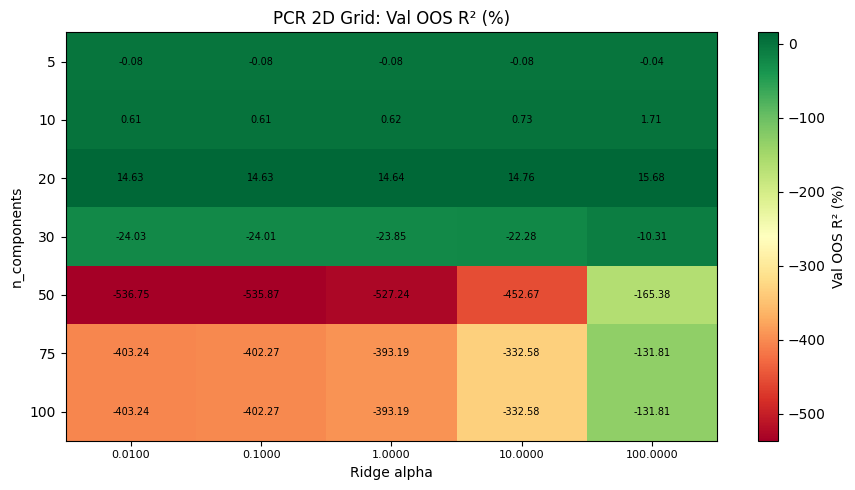

In [6]:
grid_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('pca', 'ridge')} for r in grid_results])
pivot   = grid_df.pivot(index='n_components', columns='alpha', values='oos_r2_val') * 100

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'{v:.4f}' for v in pivot.columns], fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('Ridge alpha')
ax.set_ylabel('n_components')
ax.set_title('PCR 2D Grid: Val OOS R² (%)')
for i, j in itertools.product(range(len(pivot.index)), range(len(pivot.columns))):
    ax.text(j, i, f'{pivot.values[i, j]:.2f}', ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=ax, label='Val OOS R² (%)')
plt.tight_layout()
plt.show()

## Step 4 — Final Evaluation on All Splits

In [7]:
best_pca   = best['pca']
best_ridge = best['ridge']

X_test_pca = best_pca.transform(X_test)
X_tr_pca   = best_pca.transform(X_train)
X_val_pca  = best_pca.transform(X_val)

preds = {
    'train': best_ridge.predict(X_tr_pca),
    'val':   best_ridge.predict(X_val_pca),
    'test':  best_ridge.predict(X_test_pca),
}

metrics = evaluate_splits(
    y_train, preds['train'], y_val, preds['val'], y_test, preds['test'],
    train_mean=y_train_mean,
)

cum_var = best_pca.explained_variance_ratio_.sum()

print('PCR — BEST MODEL EVALUATION')
print('=' * 55)
print(f"  n_components   : {best['n_components']}")
print(f"  Ridge alpha    : {best['alpha']}")
print(f"  Variance kept  : {cum_var*100:.1f}%")
print()
print(f"  Train R²       : {metrics['r2_train']*100:+.4f}%")
print(f"  Val R²         : {metrics['r2_val']*100:+.4f}%")
print(f"  Test R²        : {metrics['r2_test']*100:+.4f}%")
print()
print(f"  OOS R² Val     : {metrics['oos_r2_val']*100:+.4f}%")
print(f"  OOS R² Test    : {metrics['oos_r2_test']*100:+.4f}%")
print('=' * 55)

PCR — BEST MODEL EVALUATION
  n_components   : 20
  Ridge alpha    : 100.0
  Variance kept  : 78.9%

  Train R²       : +15.8677%
  Val R²         : +14.1760%
  Test R²        : -7473.1462%

  OOS R² Val     : +15.6820%
  OOS R² Test    : -7430.9130%


## Step 5 — Portfolio Formation & Sharpe Ratio

PCR LONG-SHORT PORTFOLIO
  Months         : 552
  Mean monthly   : 5.7889%
  Std monthly    : 6.7347%
  Sharpe (ann.)  : 2.9776


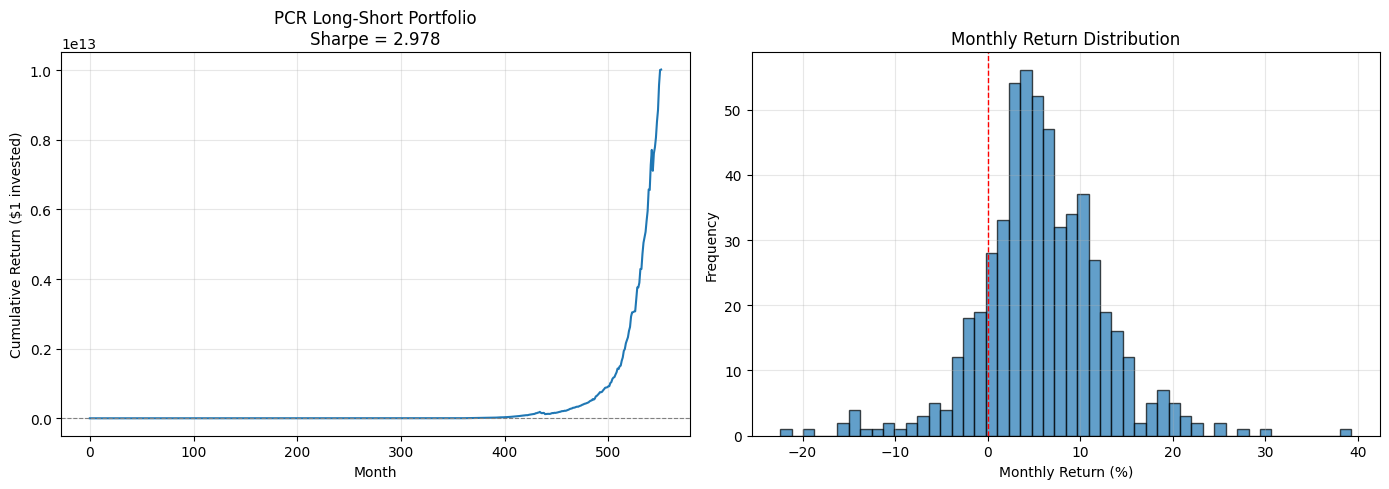

In [8]:
test_df_base = df.loc[y_test.index, [CONFIG['DATE_COL'], CONFIG['ID_COL'], CONFIG['TARGET_COL']]].copy()
test_df_base['predicted_ret'] = preds['test']
test_df_base = test_df_base.rename(columns={CONFIG['TARGET_COL']: 'actual_ret'})

port_returns, comp_df = form_long_short_portfolio(
    test_df_base, date_col=CONFIG['DATE_COL'],
    pred_col='predicted_ret', ret_col='actual_ret',
    n_deciles=CONFIG['N_DECILES'],
)
port_stats = portfolio_summary(port_returns)

print('PCR LONG-SHORT PORTFOLIO')
print('=' * 50)
print(f"  Months         : {port_stats['n_periods']}")
print(f"  Mean monthly   : {port_stats['mean_period_return']*100:.4f}%")
print(f"  Std monthly    : {port_stats['std_period_return']*100:.4f}%")
print(f"  Sharpe (ann.)  : {port_stats['sharpe_annualized']:.4f}")
print('=' * 50)

cumulative = (1 + port_returns).cumprod()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(len(cumulative)), cumulative.values, linewidth=1.5)
axes[0].axhline(y=1, color='gray', linestyle='--', linewidth=0.8)
axes[0].set(xlabel='Month', ylabel='Cumulative Return ($1 invested)',
            title=f'PCR Long-Short Portfolio\nSharpe = {port_stats["sharpe_annualized"]:.3f}')
axes[0].grid(True, alpha=0.3)
axes[1].hist(port_returns.values * 100, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[1].set(xlabel='Monthly Return (%)', ylabel='Frequency', title='Monthly Return Distribution')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6 — Save Results

In [9]:
if CONFIG['SAVE_RESULTS']:
    summary = build_run_summary(
        model_name    = 'PCR',
        description   = f'Principal Components Regression (n_components={best["n_components"]}, Ridge alpha={best["alpha"]})',
        tuning_params = f"n_components={best['n_components']}, alpha={best['alpha']}, variance_kept={cum_var*100:.1f}%",
        metrics       = metrics,
        portfolio_stats = port_stats,
        split_info    = split_info,
        n_features    = len(feature_cols),
        fill_value    = CONFIG['MISSING_FILL_VALUE'],
        standardized  = CONFIG['STANDARDIZE'],
        notebook      = 'pcr_regression',
    )
    path = save_run_summary(summary, CONFIG['OUTPUT_DIR'], 'pcr_summary.csv')
    print(f'Saved: {path}')
    path = save_portfolio_compositions(comp_df, CONFIG['OUTPUT_DIR'], 'pcr_portfolios.csv')
    print(f'Saved: {path}')
else:
    print('SAVE_RESULTS = False — skipping.')

Saved: results/pcr_summary.csv
Saved: results/pcr_portfolios.csv
